In [2]:
!ls /kaggle/working/

nlp  rl  robotics  vision


In [3]:
!pip install opencv-python-headless stable-baselines3 tensorboard pybullet --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 MB 23.6 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 3.4 MB/s eta 0:00:00:00:01


In [4]:
import sys
sys.path.insert(0, '/kaggle/working')

import numpy as np
from stable_baselines3.common.callbacks import BaseCallback

class SuccessRateCallback(BaseCallback):
    """Tracks success rate across episodes."""
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_successes = []
        self.current_episode_success = False
    
    def _on_step(self):
        infos = self.locals.get('infos', [])
        for info in infos:
            if info.get('is_success', False):
                self.current_episode_success = True
        
        # Check if any env terminated (episode ended)
        dones = self.locals.get('dones', [])
        for done in dones:
            if done:
                self.episode_successes.append(self.current_episode_success)
                self.current_episode_success = False
                
                # Log every 10 episodes
                if len(self.episode_successes) % 10 == 0:
                    recent = self.episode_successes[-50:]
                    rate = np.mean(recent)
                    self.logger.record('custom/success_rate', rate)
        
        return True

2026-05-08 10:47:55.639997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778237275.853415      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778237275.918244      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778237276.424199      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237276.424234      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778237276.424237      57 computation_placer.cc:177] computation placer alr

In [5]:
import os, sys
from stable_baselines3.common.callbacks import CheckpointCallback
sys.path.insert(0, '/kaggle/working')
os.chdir('/kaggle/working')
os.makedirs("checkpoints", exist_ok=True)

from stable_baselines3 import PPO
from rl.train import make_vec_env
from rl.feature_extractor import LanguageConditionedFeatureExtractor

env = make_vec_env(num_envs=4)

policy_kwargs = dict(
    features_extractor_class=LanguageConditionedFeatureExtractor,
    features_extractor_kwargs=dict(features_dim=256),
)

success_cb = SuccessRateCallback()

model = PPO(
    "MultiInputPolicy", env,
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log="./logs/",
    learning_rate=3e-4,
    n_steps=1024,
    ent_coef=0.01,
    clip_range=0.2,
    n_epochs=10,
)

# Checkpoint every 25K steps
checkpoint_cb = CheckpointCallback(save_freq=25000, save_path="./checkpoints/", name_prefix="ppo_alpha")

model.learn(total_timesteps=100000, callback=[success_cb, checkpoint_cb])
model.save("checkpoints/final_ppo_policy")
print("TRAINING DONE")

pybullet build time: May  8 2026 10:46:21


[Vision] Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


[Vision] ResNet18 extractor ready — output: 512-dim per crop


2026-05-08 10:48:25.236449: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-08 10:48:25.244881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778237305.277114    1037 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778237305.284775    1036 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778237305.290325    1037 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
E0000 00:00:1778237305.297800    1036 cuda_blas.cc:1

Using cuda device
Logging to ./logs/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 454      |
|    ep_rew_mean     | -0.203   |
|    success_rate    | 0.125    |
| time/              |          |
|    fps             | 19       |
|    iterations      | 1        |
|    time_elapsed    | 207      |
|    total_timesteps | 4096     |
---------------------------------
-----------------------------------------
| custom/                 |             |
|    success_rate         | 0.1         |
| rollout/                |             |
|    ep_len_mean          | 477         |
|    ep_rew_mean          | -0.362      |
|    success_rate         | 0.0625      |
| time/                   |             |
|    fps                  | 19          |
|    iterations           | 2           |
|    time_elapsed         | 415         |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.01172200

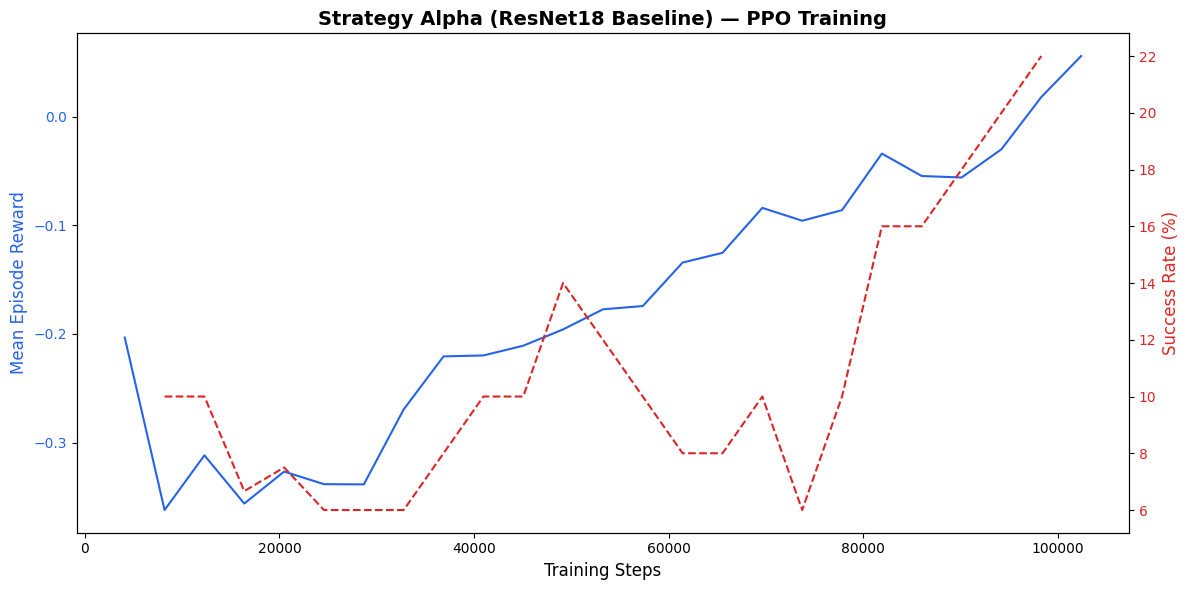

Saved: alpha_training_results.png


In [6]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import numpy as np

# Find latest log folder
log_dir = '/kaggle/working/logs/'
for folder in sorted(os.listdir(log_dir)):
    if 'PPO' in folder:
        log_folder = os.path.join(log_dir, folder)

ea = EventAccumulator(log_folder)
ea.Reload()

# --- Reward curve ---
reward = ea.Scalars('rollout/ep_rew_mean')
r_steps = [x.step for x in reward]
r_vals = [x.value for x in reward]

# --- Success rate curve ---
success = ea.Scalars('custom/success_rate')
s_steps = [x.step for x in success]
s_vals = [x.value * 100 for x in success]  # convert to percentage

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Reward on left axis
color1 = '#2563eb'
ax1.set_xlabel('Training Steps', fontsize=12)
ax1.set_ylabel('Mean Episode Reward', color=color1, fontsize=12)
ax1.plot(r_steps, r_vals, color=color1, linewidth=1.5, label='Episode Reward')
ax1.tick_params(axis='y', labelcolor=color1)

# Success rate on right axis
ax2 = ax1.twinx()
color2 = '#dc2626'
ax2.set_ylabel('Success Rate (%)', color=color2, fontsize=12)
ax2.plot(s_steps, s_vals, color=color2, linewidth=1.5, linestyle='--', label='Success Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Strategy Alpha (ResNet18 Baseline) — PPO Training', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig('/kaggle/working/alpha_training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: alpha_training_results.png')